In [2]:
from nl_vlm import PropGeom, PropMesh, Vehicle, VLM, WindField
from nl_vlm.dynamics.rotor import rotate_vehicle_mesh
from nl_vlm.preprocess import generate_polars
from nl_vlm.reporting import SimReporter

import numpy as np
import pyvista as pv

# ------------------------------- parameters -------------------------------
rho = 1.07175               # density [kg/m^3]
rpm = 5400                  # rotational speed [rpm]
dt = 0.01
R_tip = 0.12                # tip radius [m]
R_hub = 0.00624
num_blades = 2
J = 0.0                     # advance ratio; 0 = hover

# --- atmosphere (feeds the polar Re/Mach) ---
mu = 1.81e-5                # dynamic viscosity [Pa*s]
a_sound = 343.0             # speed of sound [m/s]

# --- XFOIL alpha sweep (polar generation) ---
alpha_i = -7.0              # start alpha [deg]
alpha_f = 17.0              # end alpha [deg]
alpha_step = 0.25           # alpha increment [deg]

com_position = np.array([0, 0, 0])
initial_body_velocity = np.array([0, 0, 0])
initial_euler_attitude = np.array([0, 0, 0])   # (roll, pitch, yaw) [rad]

# --------------------------------- paths ----------------------------------
BLADE_DIR   = '../data/blades/dji_9443'
AIRFOIL_DIR = '../data/airfoils/dji_9443'
POLAR_DIR   = '../data/polars/dji_9443'
XFOIL_EXE   = '../tools/xfoil/xfoil.exe'   # not installed with nl_vlm; vendored here

airfoil_dist_file = f'{BLADE_DIR}/DJI9443_airfoildist.csv'
chorddist_file    = f'{BLADE_DIR}/DJI9443_chorddist.csv'
pitchdist_file    = f'{BLADE_DIR}/DJI9443_pitchdist.csv'
sweepdist_file    = f'{BLADE_DIR}/DJI9443_sweepdist.csv'
heightdist_file   = f'{BLADE_DIR}/DJI9443_heightdist.csv'

# ----------------------------- polar couplings -----------------------------
#   nonlinear_lift : converge gamma against Cl_polar(alpha_eff) -> real lift slope + stall
#   profile_drag   : add 0.5*rho*V^2*c*ds*Cd along the local wind
nonlinear_lift = True
profile_drag = True

# --------------------------- polar generation ------------------------------
# Off by default: XFOIL solves every station, which takes a while. Flip to True to
# rebuild POLAR_DIR at the parameters above -- do that whenever rpm, R_tip, J or rho
# change, since Re and Mach follow from them and a polar set is only valid near the
# point it was built at. It also rewrites the airfoildist's 'Aero file' column
REGENERATE_POLARS = False

if REGENERATE_POLARS:
    generate_polars(
        airfoil_dist_file=airfoil_dist_file,
        chorddist_file=chorddist_file,
        airfoil_dir=AIRFOIL_DIR,
        out_dir=POLAR_DIR,
        xfoil_exe=XFOIL_EXE,
        R_tip=R_tip, rpm=rpm, J=J,
        rho=rho, mu=mu, a_sound=a_sound,
        alpha_i=alpha_i, alpha_f=alpha_f, alpha_step=alpha_step,
    )

# ------------------------------- geometry / mesh -------------------------------
geometry = PropGeom(
    airfoil_distribution_file=airfoil_dist_file,
    chorddist_file=chorddist_file,
    pitchdist_file=pitchdist_file,
    sweepdist_file=sweepdist_file,
    heightdist_file=heightdist_file,
    airfoil_path=AIRFOIL_DIR,
    polar_path=POLAR_DIR,
    R_tip=R_tip, R_hub=R_hub, num_blades=num_blades,
)
propeller_mesh = PropMesh(geometry, span_resolution=15, chord_resolution=7)
vehicle = Vehicle(propeller_mesh, hub_positions=None, spin_directions=[1])
vehicle_mesh = vehicle.generate_vehicle()

omega_rad = rpm * 2 * np.pi / 60
omega_dict = {'Propeller_1': np.array([0, 0, omega_rad])}
magVinf = J * rpm / 60 * (2 * R_tip)
freestream = np.array([0, 0, -magVinf])

# ------------------------- time-stepping over azimuth -------------------------
n_rev      = 1                       # number of revolutions
n_step_rev = 1                     # steps per ONE revolution
total_steps = n_rev * n_step_rev     # total time steps
d_psi = 2 * np.pi / n_step_rev        # azimuth turned each step [rad]


forces, moments = [], []
solved_mesh = None

vlm_solver = VLM(vehicle_mesh, propeller_mesh,
                 nonlinear_lift=nonlinear_lift, profile_drag=profile_drag)

forces_and_moments = vlm_solver.calculate_total_forces_and_moments(
    propeller_mesh=vehicle_mesh,
    dt=dt, rho=rho, time_step=1,
    body_velocity=initial_body_velocity,
    freestream=freestream,
    omega=omega_dict,
    wind_field=None,
    com_position=com_position,
    euler_angles=initial_euler_attitude,
)

solved_mesh = vehicle_mesh


# for step in range(total_steps):
#     psi = step * d_psi
#     mesh = rotate_vehicle_mesh(vehicle_mesh, {'Propeller_1': psi})            # rotate blade
#     solver = VLM(mesh, propeller_mesh, verbose=False,                         # solve VLM (quiet)
#                  nonlinear_lift=nonlinear_lift, profile_drag=profile_drag)
#     fm = solver.calculate_total_forces_and_moments(
#         propeller_mesh=mesh, dt=dt, rho=rho, time_step=step + 1,
#         body_velocity=initial_body_velocity, freestream=freestream,
#         omega=omega_dict, wind_field=None, com_position=com_position,
#         euler_angles=initial_euler_attitude,
#     )
#     forces.append(fm['Propeller_1']['force'])
#     moments.append(fm['Propeller_1']['moment'])
#     if step == 0:
#         solved_mesh = mesh   # azimuth-0 solved snapshot -> used by the plots below
#     sim.step(step + 1)       # advance the time-step progress bar

# sim.summary(np.mean(forces, axis=0), np.mean(moments, axis=0))   # mean thrust over the run

  NL-VLM  |  analysis starting
  Rotors        : 1
  Blades/rotor  : 2
  Resolution    : 15 span x 7 chord  (168 panels)
  Rotor speed   : 5400 rpm  (565.5 rad/s)
  Air density   : 1.0717 kg/m^3
  Freestream    : [ 0.  0. -0.] m/s
--------------------------------------------------------
  solving Propeller_1  [########################] 100.0%   lift coupling converged in 151 iters   res 9.6e-07      
--------------------------------------------------------
  VLM solved
    Propeller_1:  thrust Fz = +1.9874 N    torque Mz = -3.2704e-02 N*m


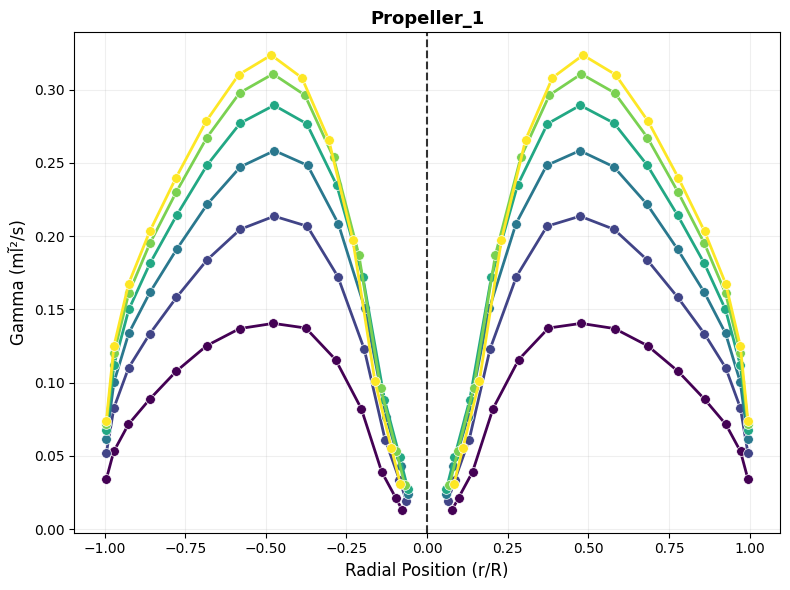

In [3]:
import matplotlib.pyplot as plt

propeller_key = 'Propeller_1'

propeller_data = solved_mesh[propeller_key]

fig, ax = plt.subplots(figsize=(8, 6))

cmap = plt.cm.viridis
chordwise_indices = sorted(set(cp_index[0] for blade_data in propeller_data['Blades'].values() 
                               for cp_index in blade_data['Control Points'].keys()))
colors = cmap(np.linspace(0, 1, len(chordwise_indices)))

for blade_idx, (blade_key, blade_data) in enumerate(propeller_data['Blades'].items()):
    for chord_idx in chordwise_indices:
        gamma_values = []
        radial_positions = []
        
        for cp_index, control_point in blade_data['Control Points'].items():
            if cp_index[0] == chord_idx:
                gamma = blade_data['Gamma'][cp_index]
                r = np.sqrt(control_point[0]**2 + control_point[1]**2)
                r_R = r / geometry.R_tip
                gamma_values.append(gamma)
                radial_positions.append(r_R)
        
        if radial_positions:
            sorted_data = sorted(zip(radial_positions, gamma_values))
            radial_positions, gamma_values = zip(*sorted_data)
            x_positions = [-r for r in radial_positions] if blade_idx == 0 else list(radial_positions)
            ax.plot(x_positions, gamma_values,
                    color=colors[chord_idx % len(colors)],
                    linewidth=2.0, marker='o', markersize=7,
                    markerfacecolor=colors[chord_idx % len(colors)],
                    markeredgecolor='white', markeredgewidth=0.5)

ax.axvline(x=0, color='black', linestyle='--', alpha=0.8, linewidth=1.5)
ax.set_xlabel('Radial Position (r/R)', fontsize=12)
ax.set_ylabel('Gamma (mآ²/s)', fontsize=12)
ax.set_title(f'{propeller_key}', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_27380\2920490999.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


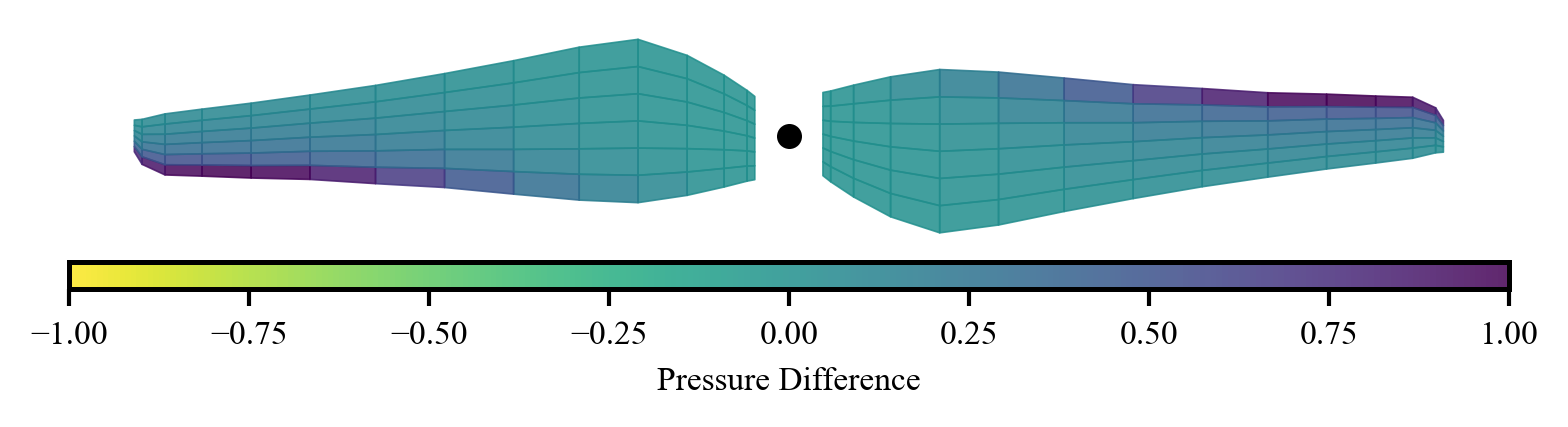

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 1.2
})

propeller_key = 'Propeller_1'
propeller_data = solved_mesh[propeller_key]

fig = plt.figure(figsize=(6, 3), dpi=300)
ax = fig.add_axes([0.1, 0.2, 0.8, 0.7])

hub_position = np.array(propeller_data['Hub Position'])
blade_keys = list(propeller_data['Blades'].keys())

all_pressures = [p for blade_key in blade_keys 
                 for p in propeller_data['Blades'][blade_key]['Pressure Difference'].values()]
max_abs_pressure = max(abs(min(all_pressures)), abs(max(all_pressures)))

patches = []
pressure_values = []

for blade_key in blade_keys:
    blade_data = propeller_data['Blades'][blade_key]
    for panel_index, panel in blade_data['Panels'].items():
        patches.append(Polygon([(-p[1], p[0]) for p in panel], closed=True))
        pressure = blade_data['Pressure Difference'][panel_index]
        pressure = max(pressure, 0)
        pressure_values.append(pressure / max_abs_pressure if max_abs_pressure != 0 else 0)

collection = PatchCollection(
    patches,
    cmap='viridis_r',
    alpha=0.85,
    edgecolors='face',
    linewidths=0.4,
    antialiased=True
)

collection.set_array(np.array(pressure_values))

vmin = -max(abs(min(pressure_values)), abs(max(pressure_values)))
collection.set_clim(vmin, -vmin)

ax.add_collection(collection)

# --- Colorbar position---
cax = fig.add_axes([0.1, 0.38, 0.8, 0.03])
cbar = plt.colorbar(collection, cax=cax, orientation='horizontal')
cbar.set_label('Pressure Difference')
cbar.ax.tick_params(length=4, width=1)
cbar.set_label('Pressure Difference', fontsize=8)
cbar.ax.tick_params(labelsize=8) 

all_points = np.array([(-p[1], p[0]) for blade_key in blade_keys
                       for panel in propeller_data['Blades'][blade_key]['Panels'].values()
                       for p in panel])

x_min, y_min = np.min(all_points, axis=0)
x_max, y_max = np.max(all_points, axis=0)
margin = 0.05

ax.set_xlim(x_min - margin*(x_max-x_min), x_max + margin*(x_max-x_min))
ax.set_ylim(y_min - margin*(y_max-y_min), y_max + margin*(y_max-y_min))
ax.set_aspect('equal')

ax.plot(-hub_position[1], hub_position[0], 'ko', markersize=5)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

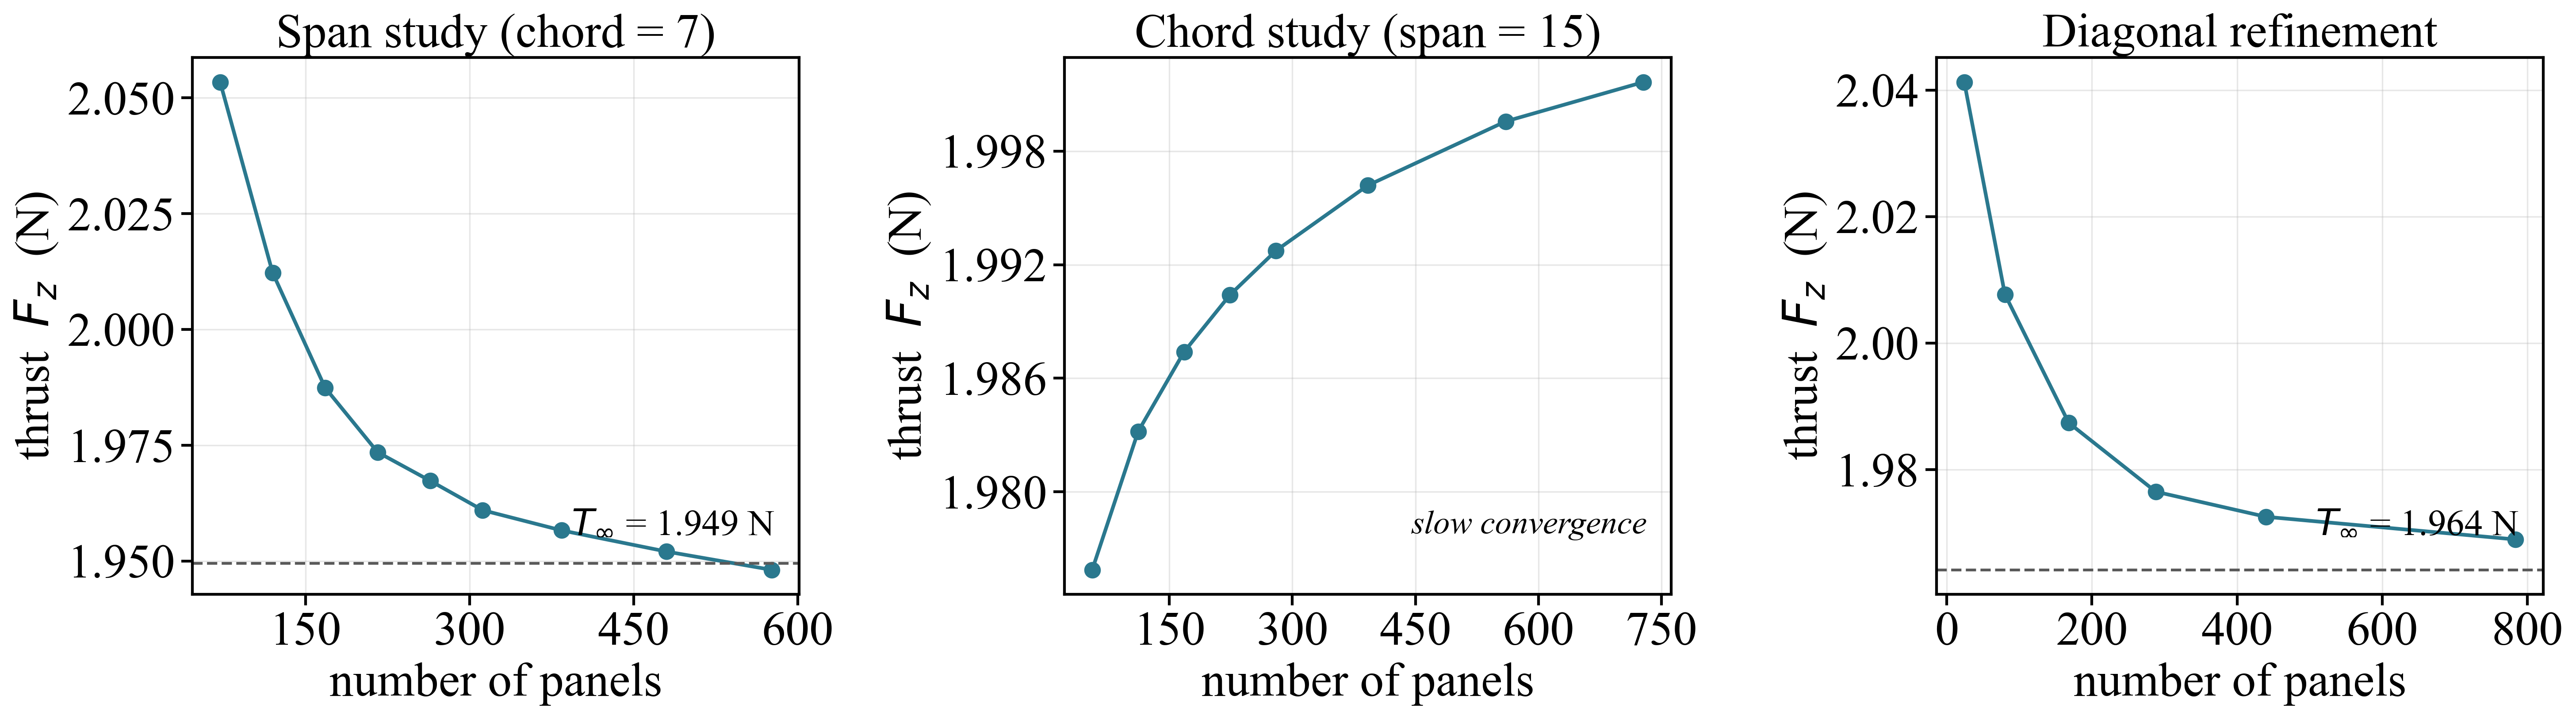

In [5]:
# ------------------------- mesh convergence study -------------------------
# Refines the panel mesh along three paths (span, chord, diagonal) and extrapolates
# the thrust to zero grid spacing (Richardson, r=2). Reuses mesh_convergence.py (same
# folder) so the notebook and the script can never drift apart.
# NOTE: this solves ~25 meshes, the largest ~2500 panels -> expect several minutes.
#
# T(inf) below is the h->0 EXTRAPOLATION, not the 15 x 7 thrust the cells above print.
# the gap is discretization error, not a bug.
import matplotlib.pyplot as plt
from mesh_convergence import run_study, richardson

span_cases  = [(s, 7) for s in (7, 11, 15, 19, 23, 27, 33, 41, 49)]   # chord = 7
chord_cases = [(15, c) for c in (3, 5, 7, 9, 11, 15, 21, 27)]         # span = 15
diag_cases  = [(7, 3), (11, 5), (15, 7), (19, 9), (23, 11), (29, 15)] # refine both

rich_grids = {
    "Span study (chord = 7)":  [(9, 7),  (17, 7),  (33, 7)],
    "Chord study (span = 15)": [(15, 5), (15, 9),  (15, 17)],
    "Diagonal refinement":     [(9, 5),  (17, 9),  (33, 17)],
}

studies = []
for name, cases in [("Span study (chord = 7)", span_cases),
                    ("Chord study (span = 15)", chord_cases),
                    ("Diagonal refinement", diag_cases)]:

    panels, thrust = run_study(name, cases)
    t_inf, p = richardson(rich_grids[name])

    reliable = t_inf is not None and abs(p) >= 0.5
    # if reliable:
        # print(f"  -> converged T(inf) = {t_inf:.4f} N   (Richardson r=2, order p = {p:.2f})")
    # else:
    porder = "n/a" if p is None else round(p, 2)
        # print(f"  -> no reliable asymptote (slow convergence; order p ~ {porder})")
    studies.append((panels, thrust, name, t_inf if reliable else None))

# ------------------------------- plot -------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 26,
    "axes.labelsize": 26,
    "axes.titlesize": 26,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
    "axes.linewidth": 1.5,
})

fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=300)
for ax, (panels, thrust, title, t_inf) in zip(axes, studies):
    ax.plot(panels, thrust, 'o-', color=plt.cm.viridis(0.4), markersize=8, linewidth=2.0)
    if t_inf is not None:
        ax.axhline(t_inf, ls='--', color='0.35', linewidth=1.5)
        ax.text(0.96, 0.10, rf"$T_\infty$ = {t_inf:.3f} N", transform=ax.transAxes,
                ha='right', va='bottom', fontsize=20)
    else:
        ax.text(0.96, 0.10, "slow convergence", transform=ax.transAxes,
                ha='right', va='bottom', fontsize=18, style='italic')
    ax.set_xlabel("number of panels")
    ax.set_ylabel(r"thrust  $F_z$  (N)")
    ax.set_title(title)
    ax.tick_params(axis='both', which='major', length=6, width=1.5)
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()